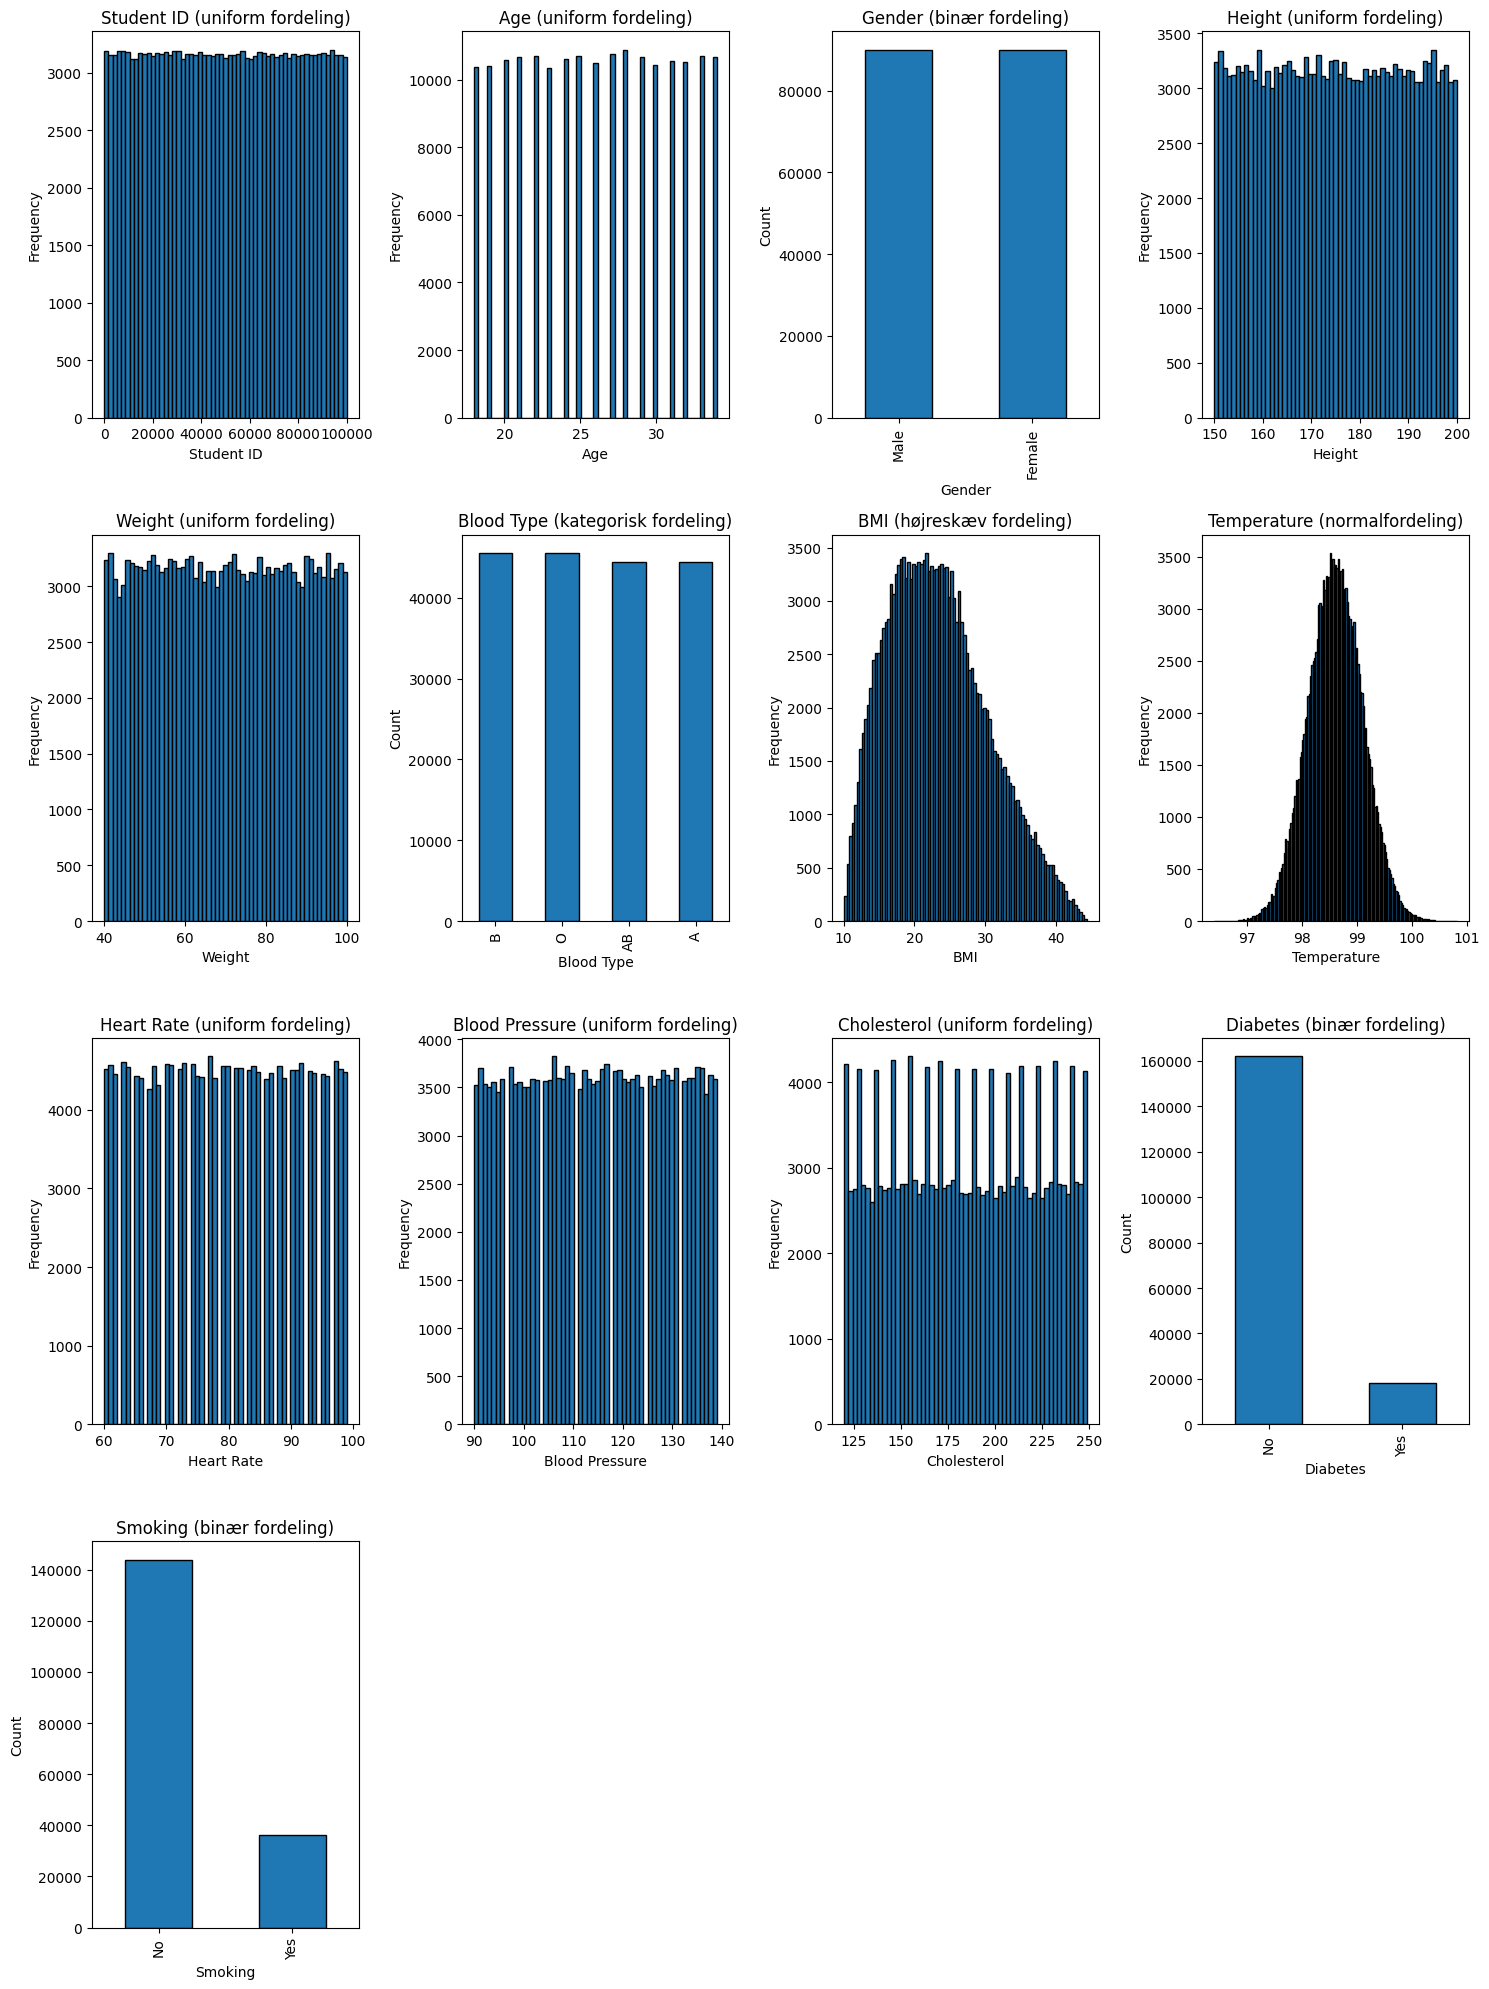

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import math

df = pd.read_csv("medical_students_dataset.csv")

cols = [
    "Student ID",
    "Age",
    "Gender",
    "Height",
    "Weight",
    "Blood Type",
    "BMI",
    "Temperature",
    "Heart Rate",
    "Blood Pressure",
    "Cholesterol",
    "Diabetes",
    "Smoking"
]

# Beskrivelse af fordeling for hver feature
distribution_labels = {
    "Student ID": "uniform fordeling",
    "Age": "uniform fordeling",
    "Gender": "binær fordeling",
    "Height": "uniform fordeling",
    "Weight": "uniform fordeling",
    "Blood Type": "kategorisk fordeling",
    "BMI": "normal fordeling",
    "Temperature": "normalfordeling",
    "Heart Rate": "uniform fordeling",
    "Blood Pressure": "uniform fordeling",
    "Cholesterol": "uniform fordeling",
    "Diabetes": "binær fordeling",
    "Smoking": "binær fordeling"
}

numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(exclude=["number"]).columns

# Brug den rækkefølge du selv har angivet i cols
all_cols = [col for col in cols if col in df.columns]

n_cols = 4
n_rows = math.ceil(len(all_cols) / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axs = axs.flatten()

for i, col in enumerate(all_cols):
    ax = axs[i]

    label = distribution_labels.get(col, "distribution")

    if col in numeric_cols:
        ax.hist(df[col].dropna(), bins="auto", edgecolor="black")
        ax.set_title(f"{col} ({label})")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    else:
        df[col].value_counts().plot(kind="bar", ax=ax, edgecolor="black")
        ax.set_title(f"{col} ({label})")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

# Remove empty subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Feature: Student ID
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1996
Mean used for imputation: 50171.780882026214
--------------------------------------------------


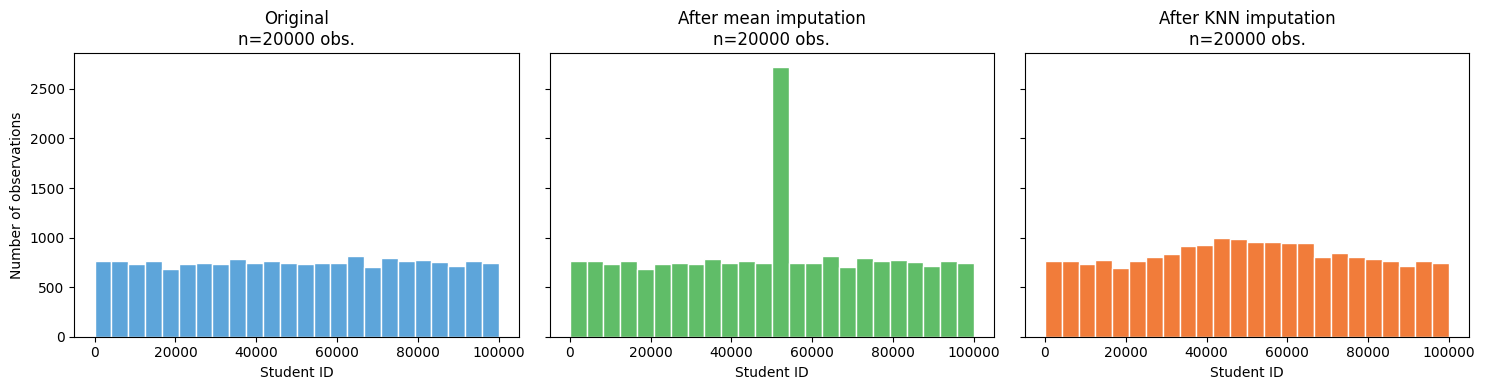

Feature: Age
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1935
Mean used for imputation: 26.0705231109881
--------------------------------------------------


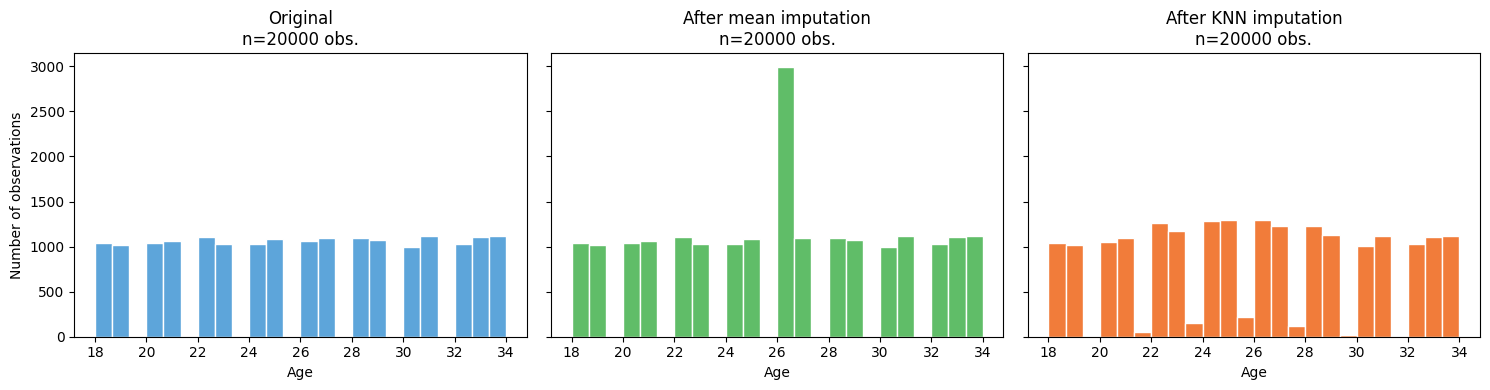

Feature: Gender
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1974
Mean used for imputation: 0.4958948185953623
--------------------------------------------------


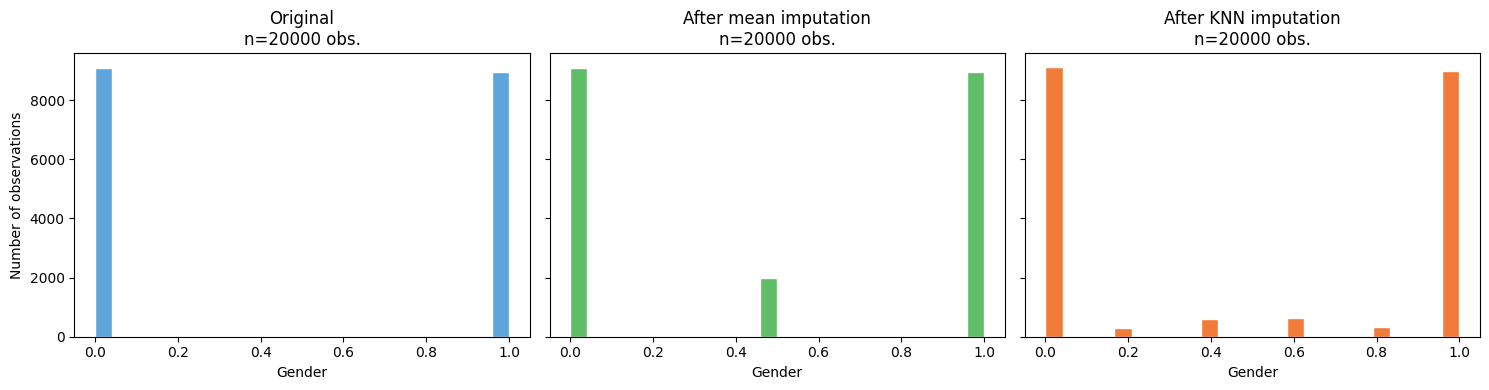

Feature: Height
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2007
Mean used for imputation: 174.94564465253302
--------------------------------------------------


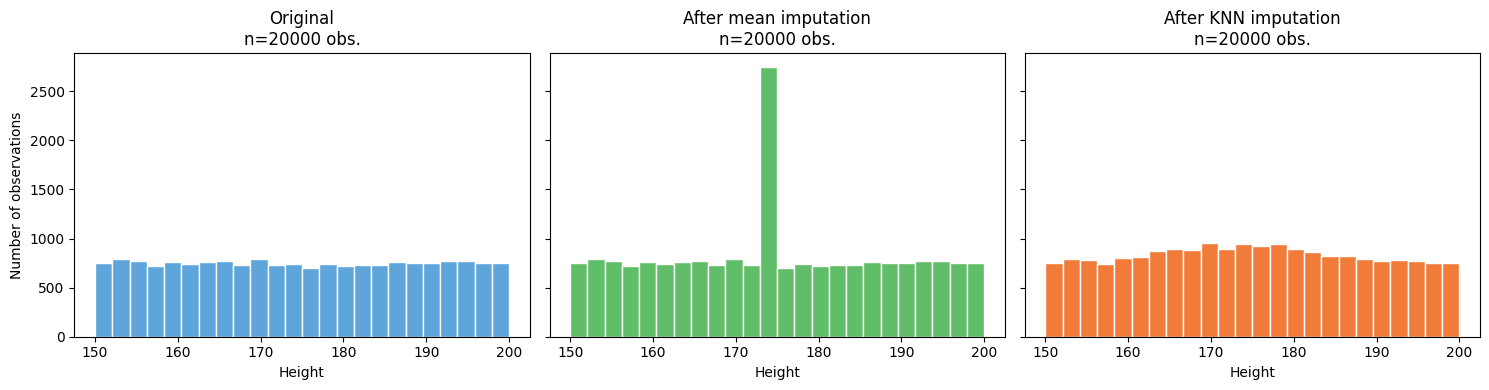

Feature: Weight
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2002
Mean used for imputation: 69.8912851212318
--------------------------------------------------


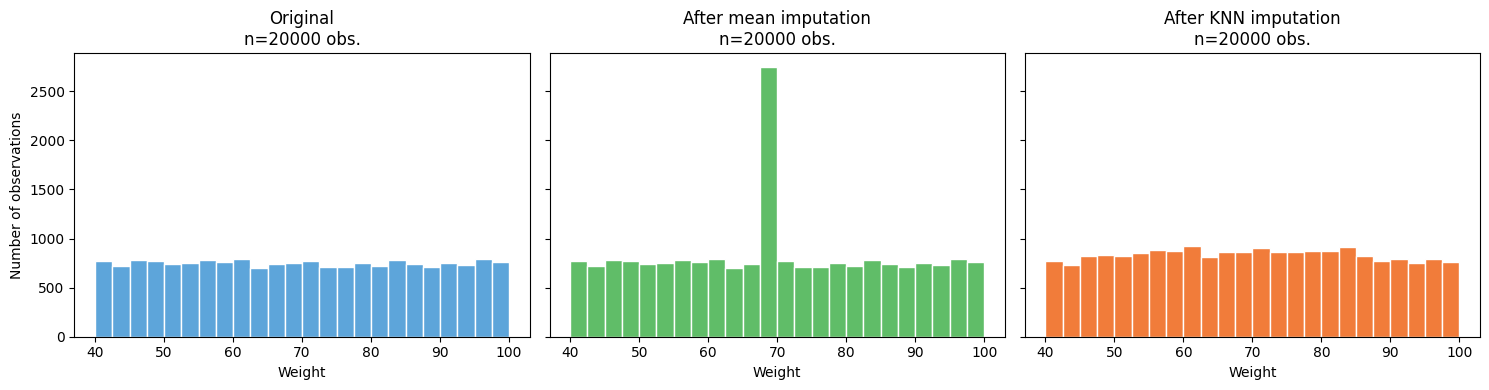

Feature: Blood Type
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2029
Mean used for imputation: 1.5219520338322854
--------------------------------------------------


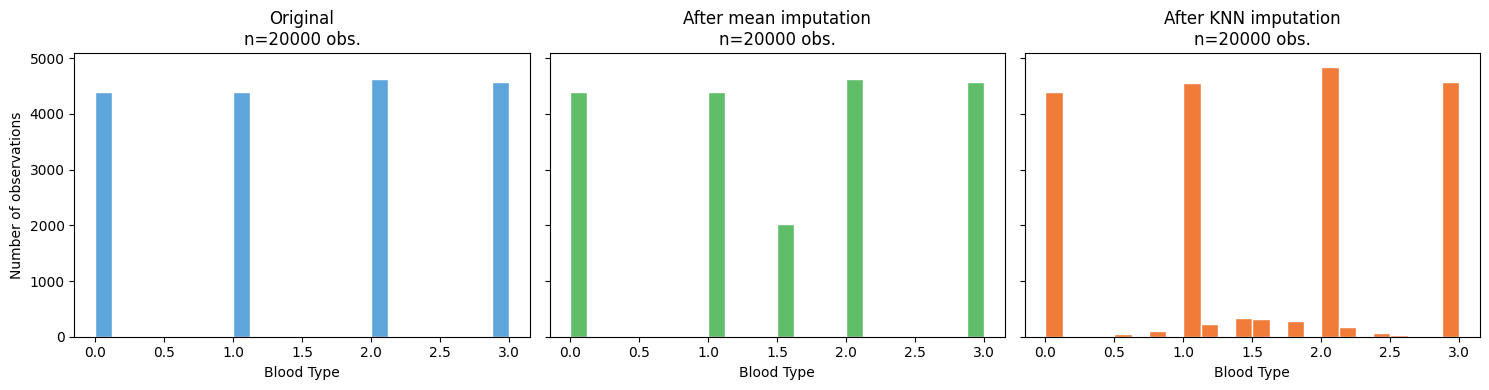

Feature: BMI
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1945
Mean used for imputation: 23.314146118653653
--------------------------------------------------


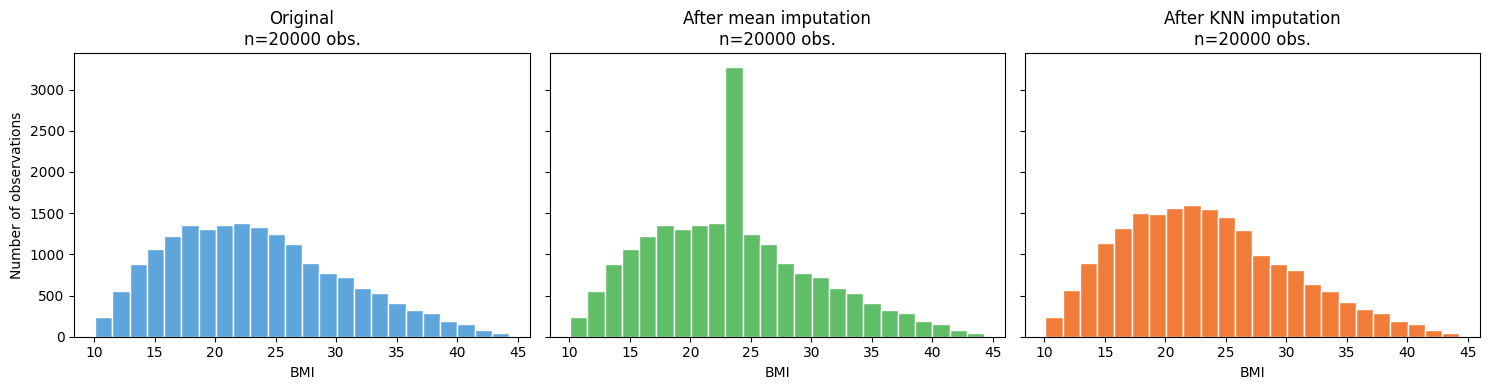

Feature: Temperature
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2087
Mean used for imputation: 98.60349899397784
--------------------------------------------------


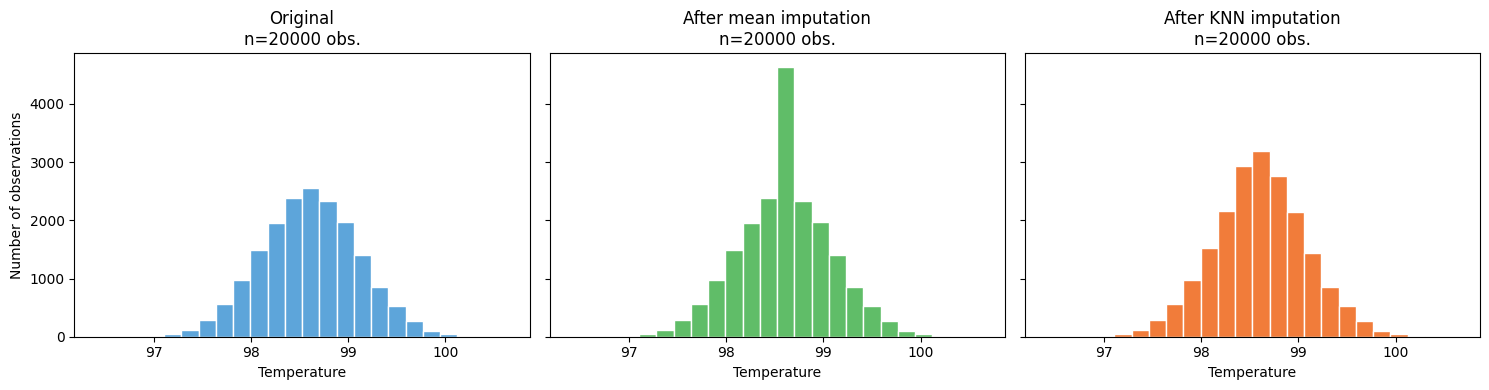

Feature: Heart Rate
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2031
Mean used for imputation: 79.58456230174188
--------------------------------------------------


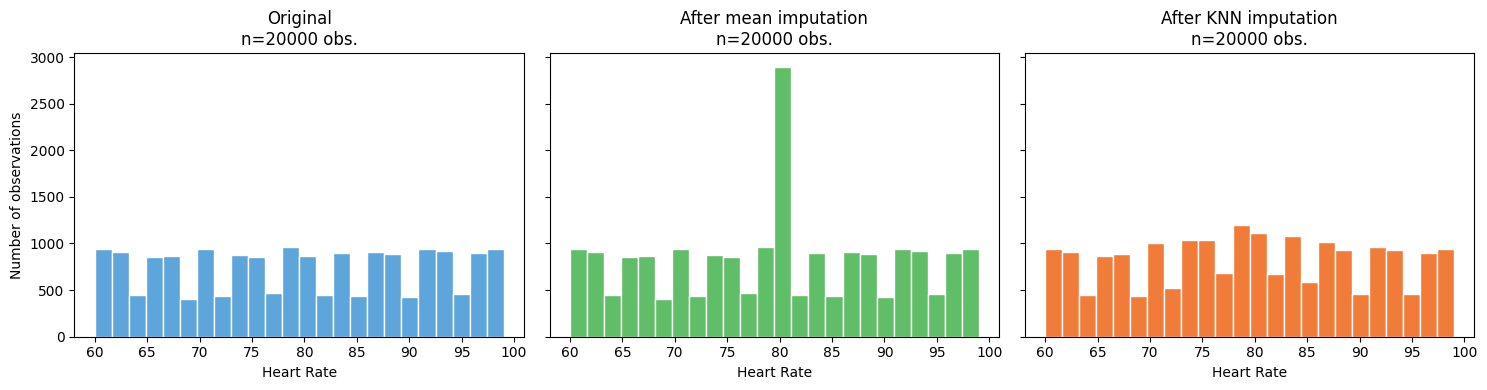

Feature: Blood Pressure
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1989
Mean used for imputation: 114.41752262506246
--------------------------------------------------


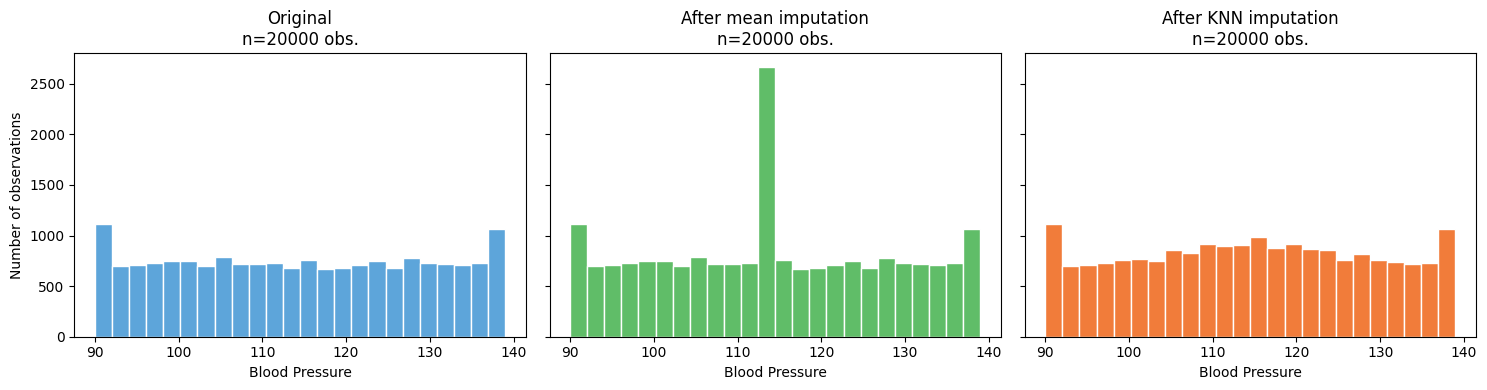

Feature: Cholesterol
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2013
Mean used for imputation: 184.5656863290154
--------------------------------------------------


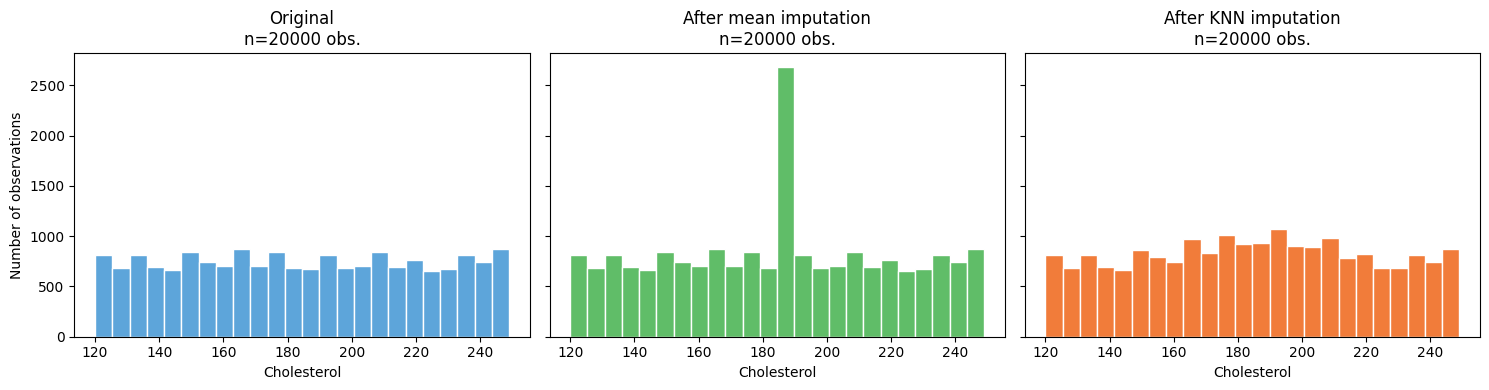

Feature: Diabetes
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 1952
Mean used for imputation: 0.10056515957446809
--------------------------------------------------


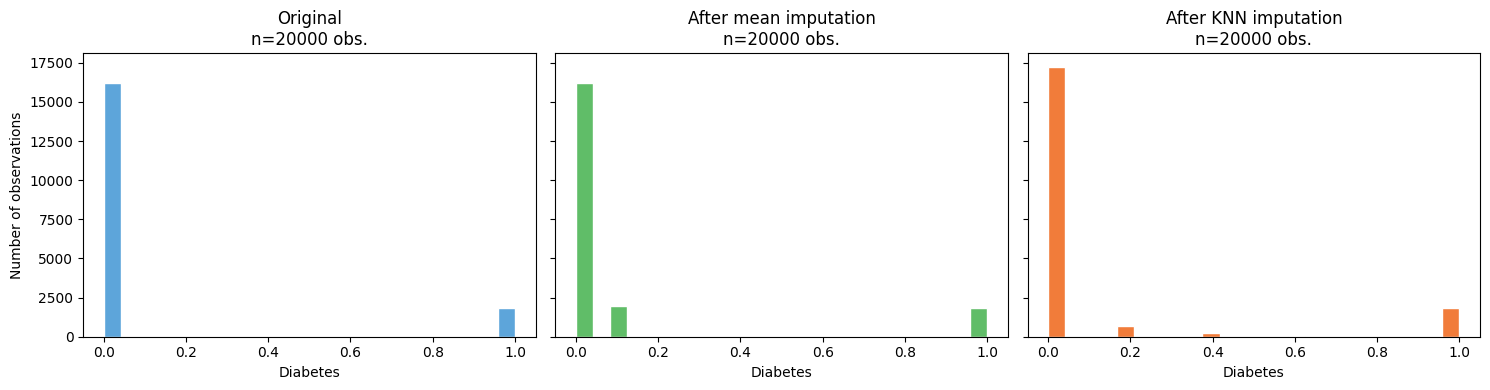

Feature: Smoking
Sample size: 20000
Original observations without missing values: 20000
Missing values before imputation: 2058
Mean used for imputation: 0.20159402519228625
--------------------------------------------------


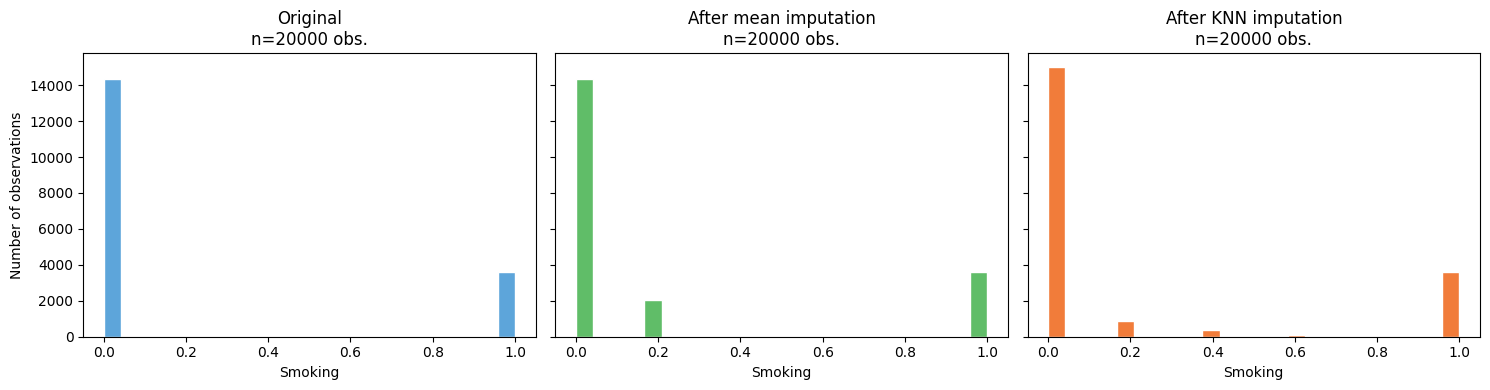

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer

# Load dataset
df = pd.read_csv("medical_students_dataset.csv")

# Vælg antal samples
sample_size = 20000
random_state = 42

# Tag sample først, så original, mean og KNN bruger præcis samme rækker
if len(df) > sample_size:
    df_sample = df.sample(n=sample_size, random_state=random_state)
else:
    df_sample = df.copy()

# Kopi af sample
df_encoded = df_sample.copy()

# Konverter kategoriske kolonner til numeriske koder
for col in df_encoded.columns:
    if not pd.api.types.is_numeric_dtype(df_encoded[col]):
        df_encoded[col] = df_encoded[col].astype("category").cat.codes

        # cat.codes laver NaN om til -1, så vi sætter dem tilbage til NaN
        df_encoded.loc[df_sample[col].isna(), col] = np.nan

# Mean imputation på sample
df_mean_imputed = df_encoded.copy()

for col in df_mean_imputed.columns:
    mean_value = df_mean_imputed[col].mean()
    df_mean_imputed[col] = df_mean_imputed[col].fillna(mean_value)

# KNN imputation på sample
knn_imputer = KNNImputer(n_neighbors=5)

df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_encoded),
    columns=df_encoded.columns,
    index=df_encoded.index
    
)

# Plot alle features
for feature in df_encoded.columns:
    original = df_encoded[feature]
    mean_imputed = df_mean_imputed[feature]
    knn_imputed = df_knn_imputed[feature]

    print(f"Feature: {feature}")
    print(f"Sample size: {len(df_sample)}")
    print(f"Original observations without missing values: {len(original)}")
    print(f"Missing values before imputation: {df_encoded[feature].isna().sum()}")
    print(f"Mean used for imputation: {df_encoded[feature].mean()}")
    print("-" * 50)

    combined_data = pd.concat([
        original,
        mean_imputed,
        knn_imputed
    ])

    # Hvis kolonnen kun har én unik værdi, undgå fejl i bins
    if combined_data.nunique() <= 1:
        bins = 5
    else:
        bins = np.linspace(
            combined_data.min(),
            combined_data.max(),
            25
        )

    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    # Original sample
    axs[0].hist(
        original,
        bins=bins,
        edgecolor="white",
        color="#5DA5DA"
    )
    axs[0].set_title(f"Original\nn={len(original)} obs.")
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel("Number of observations")

    # Mean imputation sample
    axs[1].hist(
        mean_imputed,
        bins=bins,
        edgecolor="white",
        color="#60BD68"
    )
    axs[1].set_title(f"After mean imputation\nn={len(mean_imputed)} obs.")
    axs[1].set_xlabel(feature)

    # KNN imputation sample
    axs[2].hist(
        knn_imputed,
        bins=bins,
        edgecolor="white",
        color="#F17C3A"
    )
    axs[2].set_title(f"After KNN imputation\nn={len(knn_imputed)} obs.")
    axs[2].set_xlabel(feature)

    plt.tight_layout()
    plt.show()